In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm 
import pymc.math as pm_math
import seaborn as sns

Linear prediction

In [2]:
def generate_linear_data(X : np.array, coeff : float, sigma : float):
    n = X.shape[0]
    noise = np.random.normal(loc = 0, scale = sigma, size = n)
    return coeff*X + noise

def compute_mle(x : np.array , y : np.array):
    return (x.T)@y/np.sum(x**2)


theta MLE : 0.7475975588430758
Theta : 0.75


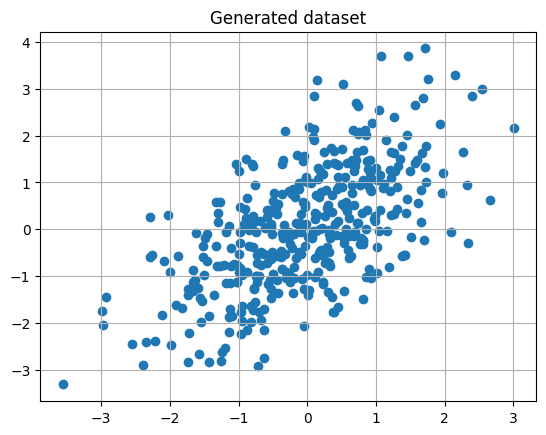

In [3]:
sigma2 = 1
theta = 0.75

X = np.random.normal(loc = 0, scale = sigma2, size = 400)
Y = generate_linear_data(X, theta, sigma2)

fig, ax = plt.subplots()
ax.scatter(X, Y)
ax.set_title("Generated dataset")
ax.grid()

print(f"theta MLE : {compute_mle(X, Y)}")
print(f"Theta : 0.75")

In [7]:
def cum_loss_L1(x, y, theta):
    return pm_math.sum(pm_math.abs(y - x*theta))

def cum_loss_L2(x, y, theta):
    return pm_math.sum((y - x*theta)**2)

def MHSample(n_sample : int, X : np.array , Y : np.array, tau : float, eta : float , loss):
    
    with pm.Model() as model:
        theta = pm.Normal("theta", mu=0, sigma=tau)
        pm.Potential("loss", -eta * loss(X, Y, theta))
        
        step = pm.Metropolis()
        trace = pm.sample(n_sample, tune=1000, step=step, cores=1, chains=2, progressbar=True)

    rhat = az.rhat(trace, var_names=["theta"])
    ess = az.ess(trace, var_names=["theta"])
    print("R-hat:", rhat["theta"].values)
    print("Effective sample size (ESS):", ess["theta"].values)
    
    return trace

Model :


$$ y = \theta x + \epsilon $$

On utilise un prior gaussien : 

$$
\theta \sim \mathcal{N}(0,\tau^2),
$$

Dans le cas du bayésien généralisé : 

$$
q(\theta | y_{1:n}) \propto e^{-\frac{\theta^2}{2\tau^2} - \eta L_n(\theta)}
$$

$$
q(\theta | y_{1:n} ) \propto e^{- (\frac{\theta^2}{2\tau^2} + \eta L_n(\theta))}
$$


In [24]:
n_sample = 1000
tau = 0.2
eta = 0.1


samples = MHSample(n_sample, X,Y, tau, eta, cum_loss_L2)

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


R-hat: 1.0113721654956127
Effective sample size (ESS): 214.0441283041522


Text(0.5, 1.0, 'Markov chains genrerated')

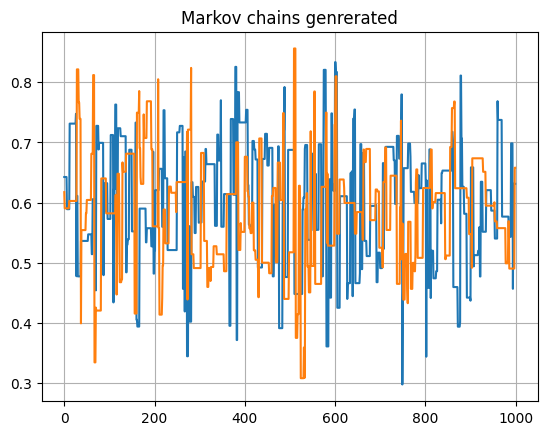

In [25]:
chain_1 = samples.posterior.theta.values[0, : ]
chain_2 = samples.posterior.theta.values[1, : ]

fig, ax = plt.subplots()
ax.plot(chain_1)
ax.plot(chain_2)
ax.grid()
ax.set_title("Markov chains genrerated")

Dans le cadre bayésien classic, le posterior est :

$\theta \mid y,X \sim \mathcal{N}(\mu_{\text{post}}, \Sigma_{\text{post}})$

Moyenne a posteriori :

$\mu_{\text{post}} =
\left(
\frac{1}{\sigma^2} X^T X + \frac{1}{\tau^2} I
\right)^{-1}
\frac{1}{\sigma^2} X^T y$

Variance (matrice de covariance) a posteriori :

$
\Sigma_{\text{post}} =
\left(
\frac{1}{\sigma^2} X^T X + \frac{1}{\tau^2} I
\right)^{-1}
$

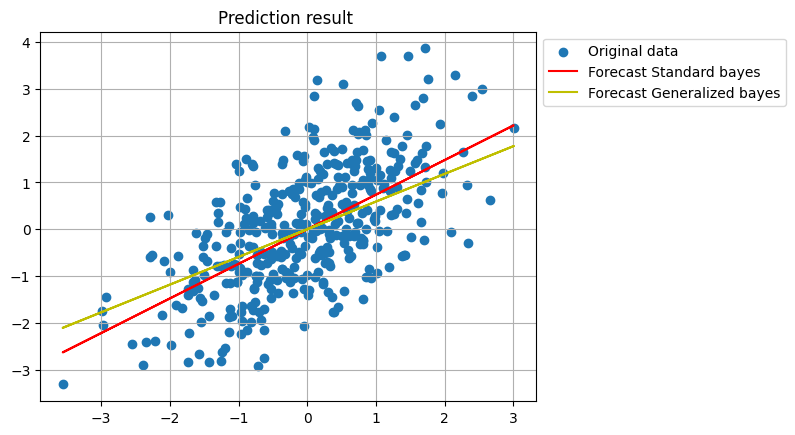

In [ ]:
mu_post = (1/(X.T@X/sigma2 + 1/tau))*X.T@Y/sigma2

y_pred_sb = mu_post*X

mcmc_theta = np.mean(np.hstack([chain_1, chain_2]))
y_pred_gb = mcmc_theta*X

fig, ax = plt.subplots()
ax.scatter(X,Y, label = "Original data")
ax.plot(X, y_pred_sb, c = 'r', label = 'Forecast Standard bayes')
ax.plot(X, y_pred_gb, c = 'y', label = 'Forecast Generalized bayes')
ax.plot()
ax.grid()
ax.set_title("Prediction result ")
ax.legend(bbox_to_anchor =(1,1))

### Effect of $\eta$

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

R-hat: 1.00645754928285
Effective sample size (ESS): 388.41842481762245


...

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


R-hat: 1.0270443859658036
Effective sample size (ESS): 310.3173252737276


Text(0.5, 1.0, 'eta impact on prediction')

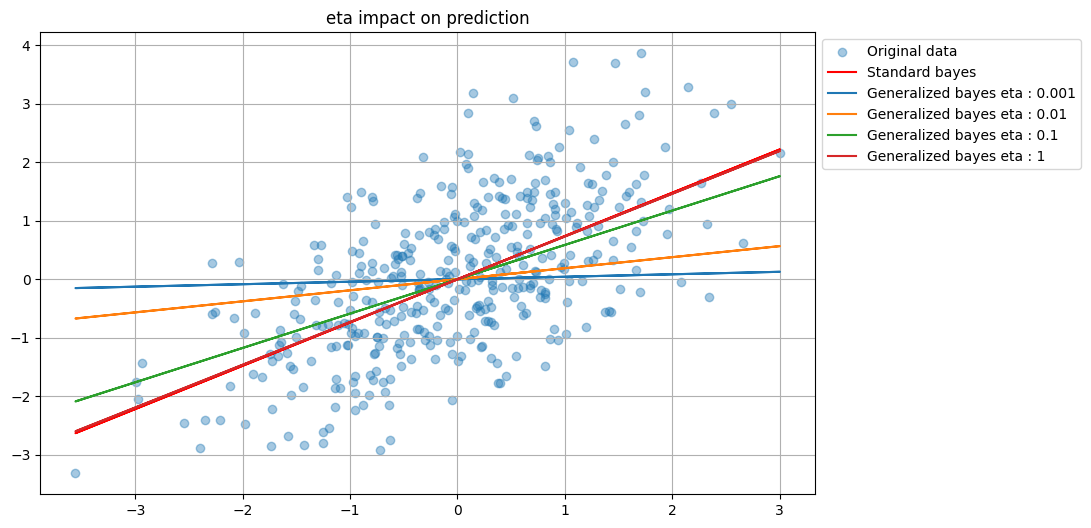

In [65]:
n_sample = 1000
tau = 0.2
etas = [0.001, 0.01, 0.1, 1]

fig, ax = plt.subplots(figsize = (10, 6))
ax.scatter(X,Y, alpha = 0.4, label = "Original data")
ax.plot(X, y_pred_sb, c = 'r', label = 'Standard bayes')
ax.grid()

for eta in etas:
    samples = MHSample(n_sample, X,Y, tau, eta, cum_loss_L2)
    chain_1 = samples.posterior.theta.values[0, : ]
    chain_2 = samples.posterior.theta.values[1, : ]
    mcmc_theta = np.mean(np.hstack([chain_1, chain_2]))
    y_pred_gb = mcmc_theta*X
    ax.plot(X, y_pred_gb, label = f'Generalized bayes eta : {eta}')

ax.legend(bbox_to_anchor = (1,1))
ax.set_title('eta impact on prediction')

### $\tau$ impact

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

R-hat: 1.0096471689190711
Effective sample size (ESS): 280.58317388168183


...

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat: 1.0093935540683667
Effective sample size (ESS): 350.5609728509077


Text(0.5, 1.0, 'tau impact on prediction')

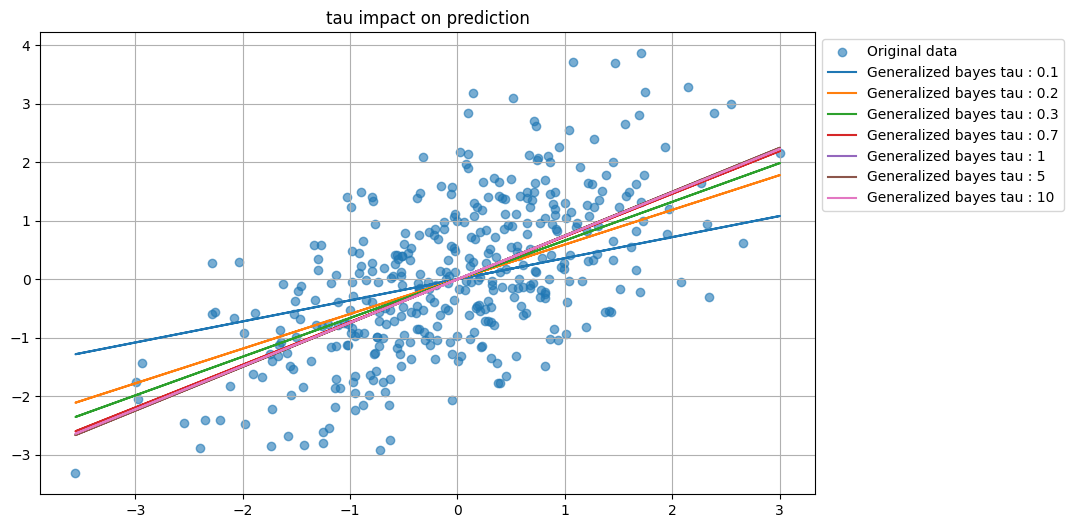

In [68]:
n_sample = 1000
taus = [0.1, 0.2, 0.3, 0.7, 1, 5, 10]
eta =  0.1

fig, ax = plt.subplots(figsize = (10, 6))
ax.scatter(X,Y, alpha = 0.6, label = "Original data")
ax.grid()

for tau in taus:
    samples = MHSample(n_sample, X,Y, tau, eta, cum_loss_L2)
    chain_1 = samples.posterior.theta.values[0, : ]
    chain_2 = samples.posterior.theta.values[1, : ]
    mcmc_theta = np.mean(np.hstack([chain_1, chain_2]))
    y_pred_gb = mcmc_theta*X
    ax.plot(X, y_pred_gb, label = f'Generalized bayes tau : {tau}')

ax.legend(bbox_to_anchor = (1,1))
ax.set_title('tau impact on prediction')

### Loss effect 

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat: 1.0070386152970472
Effective sample size (ESS): 363.34621503648503


Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


R-hat: 1.010306464820086
Effective sample size (ESS): 401.2806688297019


Text(0.5, 1.0, 'Loss impact on prediction')

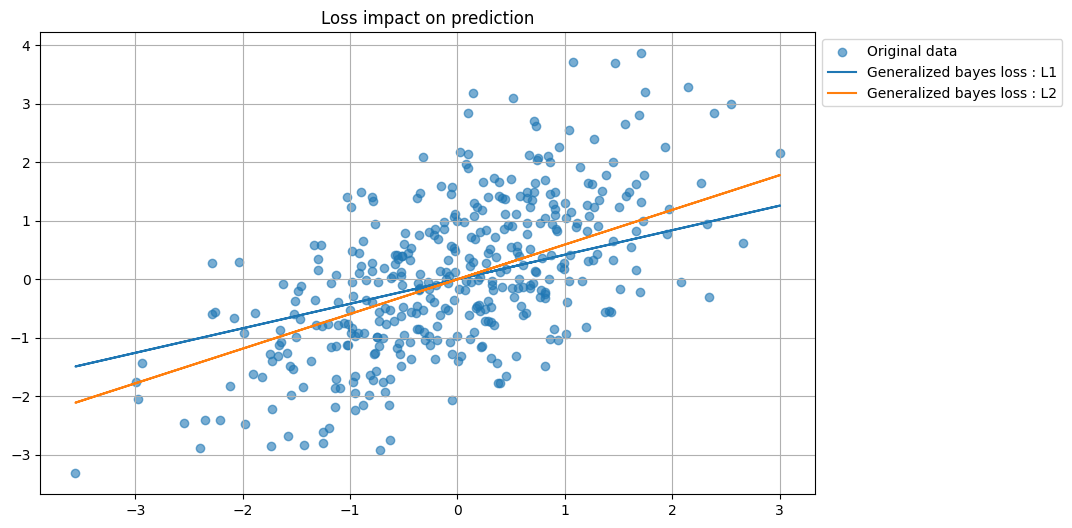

In [102]:
n_sample = 1000
tau = 0.2
eta =  0.1
losses = {"L1" : cum_loss_L1, "L2" :cum_loss_L2}

fig, ax = plt.subplots(figsize = (10, 6))
ax.scatter(X,Y, alpha = 0.6, label = "Original data")
ax.grid()


for loss in losses:

    samples = MHSample(n_sample, X,Y, tau, eta, losses[loss])
    chain_1 = samples.posterior.theta.values[0, : ]
    chain_2 = samples.posterior.theta.values[1, : ]
    mcmc_theta = np.mean(np.hstack([chain_1, chain_2]))
    y_pred_gb = mcmc_theta*X
    ax.plot(X, y_pred_gb, label = f'Generalized bayes loss : {loss}')

ax.legend(bbox_to_anchor = (1,1))
ax.set_title('Loss impact on prediction')


### Miss specified model

On suppose à tort que le modèle est exponentiel $y = e^{\theta x}$. 

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


R-hat: 1.0278224222687375
Effective sample size (ESS): 253.3888182962442


Text(0.5, 1.0, 'Generated chain')

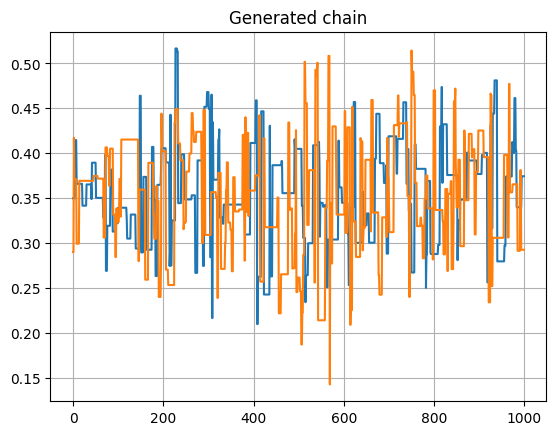

In [76]:
def cum_loss_L2_exp(x, y, theta):
    return pm_math.sum((y - np.exp(x*theta))**2)


n_sample = 1000
taus = [0.1, 0.2, 0.3, 0.7, 1, 5, 10]
eta =  0.1


samples = MHSample(n_sample, X,Y, tau, eta, cum_loss_L2_exp)
chain_1 = samples.posterior.theta.values[0, : ]
chain_2 = samples.posterior.theta.values[1, : ]

fig, ax = plt.subplots()
ax.plot(chain_1)
ax.plot(chain_2)
ax.grid()
ax.set_title("Generated chain")

On approxime par monte carlo le predicteur optimal par monte carlo :

$$\mathbb{E}[e^{X\theta} | X = x] = \frac{1}{N}\sum_{i=1}^{N} e^{x\theta_i}$$

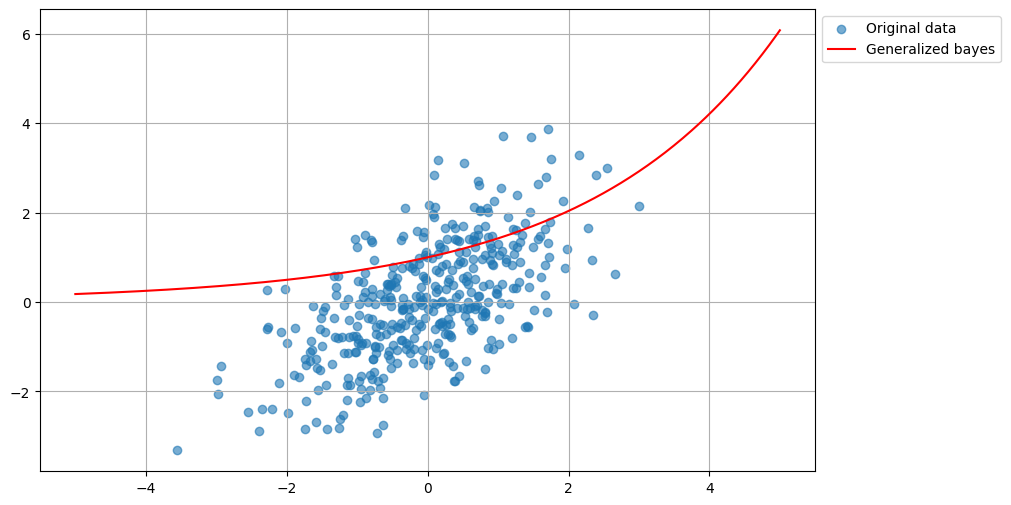

In [ ]:
thetas = np.hstack([chain_1, chain_2])

def y_predictor(x : float, thetas : np.array):
    N = thetas.shape[0]
    return np.sum(np.exp(x*thetas))/N

x_linspace = np.linspace(-5, 5, 400)
y_pred_gb = [y_predictor(k, thetas) for k in x_linspace]

fig, ax = plt.subplots(figsize = (10, 6))
ax.scatter(X,Y, alpha = 0.6, label = "Original data")
ax.plot(x_linspace,y_pred_gb, c = 'r', label = "Generalized bayes")
ax.legend(bbox_to_anchor = (1,1))
ax.grid()


Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


R-hat: 1.012296418449203
Effective sample size (ESS): 340.62505682859944


Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


...

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


R-hat: 1.0107295059885466
Effective sample size (ESS): 216.68594615587594


Text(0.5, 1.0, 'Miss specified model, eta value comparison')

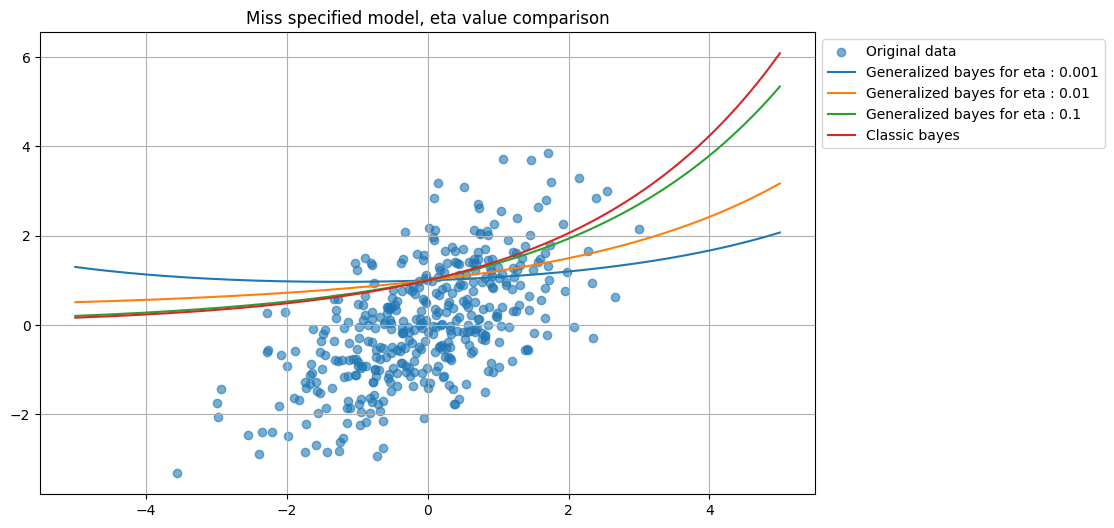

In [100]:
n_sample = 1000
tau = 0.2
etas = [0.001, 0.01, 0.1, 1]
x_linspace = np.linspace(-5, 5, 400)

fig ,ax = plt.subplots(figsize = (10, 6))
ax.scatter(X,Y, alpha = 0.6, label = "Original data")

for eta in etas:
    samples = MHSample(n_sample, X,Y, tau, eta, cum_loss_L2_exp)
    chain_1 = samples.posterior.theta.values[0, : ]
    chain_2 = samples.posterior.theta.values[1, : ]
    thetas = np.hstack([chain_1, chain_2])
    y_pred_gb = [y_predictor(k, thetas) for k in x_linspace]

    if eta == 1 :
        ax.plot(x_linspace,y_pred_gb, label = f"Classic bayes")
        continue

    ax.plot(x_linspace,y_pred_gb, label = f"Generalized bayes for eta : {eta}")

ax.grid()
ax.legend(bbox_to_anchor =(1,1))
ax.set_title("Miss specified model, eta value comparison")